# EfficientNetV2-M — autoLRP attribution

EfficientNetV2-medium from torchvision (ImageNet weights). The architecture relies on squeeze-and-excitation gates, `x * sigmoid(fc(pool(x)))`. Both operands come from the input, so the product splits its relevance in proportion to their magnitudes; `extras/02_custom_analyzer` shows how to treat the gate as a constant instead.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from torchvision.models import efficientnet_v2_m, EfficientNet_V2_M_Weights

import autolrp
from autolrp import LRPConfig
from _common import load_showcase_images, show_vision_attribution, imagenet_classes

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
model = efficientnet_v2_m(weights=EfficientNet_V2_M_Weights.DEFAULT).eval().to(device)
images = load_showcase_images(device=device)
print(f'Loaded {len(images)} showcase images')

Loaded 1 showcase images


/opt/miniconda3/envs/waleed/lib/python3.12/site-packages/torchvision/models/efficientnet.py:229: UserWarning: In-place 'add_' remapped to out-of-place 'add' for LRP graph compatibility; the original tensor is NOT modified in place. Set AUTOLRP_NO_INPLACE_REMAP=1 to disable.
  result += input


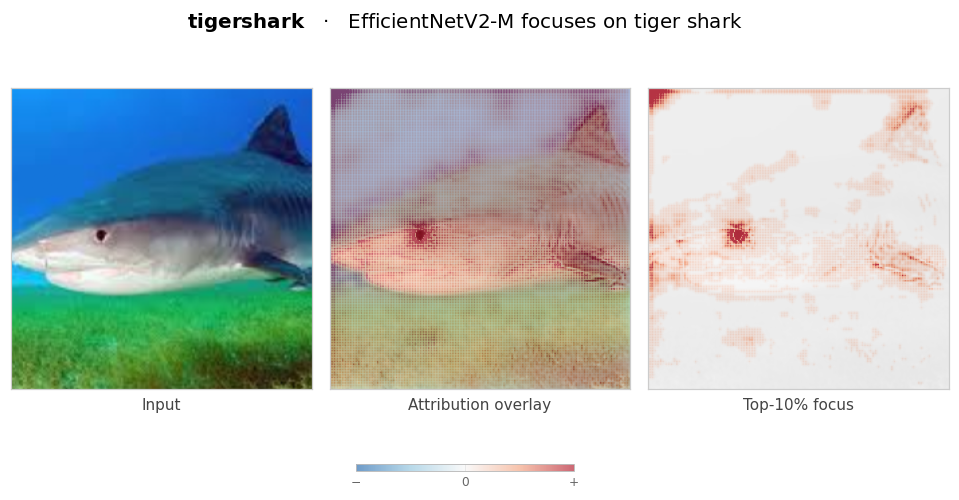

In [3]:
for img, label in images:
    with torch.no_grad():
        pred = model(img).argmax(-1).item()
    pred_name = imagenet_classes()[pred]
    x = autolrp.tensor(img.clone())
    model(x)[0, pred].lrp(config=LRPConfig.composite())
    show_vision_attribution(
        img,
        x.relevance,
        pred_label=pred_name,
        rule_name=f'EfficientNetV2-M focuses on {pred_name.lower()}'
    )